In [1]:
import os
import sys

# Đảm bảo Notebook luôn đứng ở thư mục gốc dự án
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

print(f"✅ Đang chạy tại thư mục: {os.getcwd()}")

✅ Đang chạy tại thư mục: d:\HCMUT\NMTTNT\ai-ambulance-coordinator


In [2]:
from modules.core.disease_classifier import DiseaseClassifier

print("=== CHẠY BẢN SCALE-UP: SKLEARN NAIVE BAYES ===")
clf = DiseaseClassifier(model_name="sklearnNaiveBayes")

# Truyền thẳng đường dẫn file CSV vào đây (Đảm bảo file dataset.csv đang nằm trong thư mục data/)
clf.train("data/Final_Augmented_dataset_Diseases_and_Symptoms.csv") 

# In bảng đánh giá
print("\n--- BẢNG ĐIỂM ---")
metrics = clf.evaluate()
for m, score in metrics.items():
    print(f"{m:<10}: {score * 100:.2f}%")

# Test thử chẩn đoán (Lấy tự động 2 triệu chứng đầu tiên có thật trong data)
print("\n--- TEST DỰ ĐOÁN ---")
# Trích xuất chính xác tên 2 triệu chứng từ từ điển của AI
symptom_1 = clf.symptoms_vocab[0]
symptom_2 = clf.symptoms_vocab[5] # Lấy triệu chứng số 1 và số 6

symptoms = [symptom_1, symptom_2]
print(f"Triệu chứng đầu vào: {symptoms}")
print(f"=> AI Chẩn đoán: {clf.predict(symptoms)}")

=== CHẠY BẢN SCALE-UP: SKLEARN NAIVE BAYES ===
Đang tải dữ liệu từ data/Final_Augmented_dataset_Diseases_and_Symptoms.csv...
Đang chuyển đổi sang Sparse Matrix để tăng tốc...
Đang huấn luyện mô hình sklearnNaiveBayes...
[HOÀN TẤT] Huấn luyện thành công!

--- BẢNG ĐIỂM ---
Đang đánh giá mô hình trên tập Test...
Accuracy  : 84.53%
Precision : 84.32%
Recall    : 84.53%
F1-Score  : 83.87%

--- TEST DỰ ĐOÁN ---
Triệu chứng đầu vào: ['anxiety and nervousness', 'dizziness']
=> AI Chẩn đoán: acute stress reaction


In [3]:
from modules.core.disease_classifier import DiseaseClassifier

print("=== CHẠY BẢN LÝ THUYẾT: NAIVE BAYES TỪ SCRATCH (NUMPY) ===")
# 1. Gọi tên mô hình mà bạn đã dày công code bằng tay!
clf_simple = DiseaseClassifier(model_name="simpleClassifierModel")

# 2. Huấn luyện trên cùng một bộ dữ liệu
# Lưu ý: Code thuần chạy có thể sẽ mất thêm vài giây so với bản C++ tối ưu của thư viện
clf_simple.train("data/Final_Augmented_dataset_Diseases_and_Symptoms.csv") 

# 3. In bảng đánh giá để so sánh điểm
print("\n--- BẢNG ĐIỂM ---")
metrics_simple = clf_simple.evaluate()
for m, score in metrics_simple.items():
    print(f"{m:<10}: {score * 100:.2f}%")

# 4. Test thử chẩn đoán với đúng 2 triệu chứng giống hệt cell ở trên
print("\n--- TEST DỰ ĐOÁN ---")
symptom_1 = clf_simple.symptoms_vocab[0]
symptom_2 = clf_simple.symptoms_vocab[5] 

symptoms = [symptom_1, symptom_2]
print(f"Triệu chứng đầu vào: {symptoms}")
print(f"=> AI Chẩn đoán: {clf_simple.predict(symptoms)}")

=== CHẠY BẢN LÝ THUYẾT: NAIVE BAYES TỪ SCRATCH (NUMPY) ===
Đang tải dữ liệu từ data/Final_Augmented_dataset_Diseases_and_Symptoms.csv...
Đang chuyển đổi sang Sparse Matrix để tăng tốc...
Đang huấn luyện mô hình simpleClassifierModel...
[HOÀN TẤT] Huấn luyện thành công!

--- BẢNG ĐIỂM ---
Đang đánh giá mô hình trên tập Test...
Accuracy  : 84.53%
Precision : 84.32%
Recall    : 84.53%
F1-Score  : 83.87%

--- TEST DỰ ĐOÁN ---
Triệu chứng đầu vào: ['anxiety and nervousness', 'dizziness']
=> AI Chẩn đoán: acute stress reaction


In [4]:
pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import time
import warnings
warnings.filterwarnings('ignore') # Ẩn cảnh báo đỏ

# --- 1. TẠO CÁC THÀNH PHẦN GIAO DIỆN ---
all_symptoms = list(clf.symptoms_vocab)
selected_symptoms_list = []

search_input = widgets.Text(
    placeholder='Gõ để tìm (VD: fev, head...)',
    description='🔍 Tìm:',
    layout=widgets.Layout(width='300px')
)

# Khởi tạo hộp gợi ý
suggestion_box = widgets.Select(
    options=[],
    rows=5,
    layout=widgets.Layout(width='300px', margin='0 0 0 85px')
)
suggestion_box.layout.display = 'none' # Ẩn đi lúc ban đầu

clear_btn = widgets.Button(description='🗑️ Xóa giỏ hàng', button_style='danger', layout=widgets.Layout(width='120px'))
predict_btn = widgets.Button(description='🚀 Chẩn Đoán Ngay', button_style='success')

cart_html = widgets.HTML(value="<div style='padding:10px; background:#f9f9f9; border-radius:5px;'><b>🛒 Các triệu chứng đã chọn:</b> <i>Chưa có</i></div>")
output_area = widgets.Output()

# --- 2. XỬ LÝ LOGIC TÌM KIẾM & GỢI Ý ---
def update_cart_display():
    """Cập nhật giao diện giỏ hàng"""
    if not selected_symptoms_list:
        cart_html.value = "<div style='padding:10px; background:#f9f9f9; border-radius:5px;'><b>🛒 Các triệu chứng đã chọn:</b> <i>Chưa có</i></div>"
    else:
        tags = "".join([f"<span style='background:#D4E6F1; color:#154360; padding:4px 8px; margin:3px; border-radius:15px; display:inline-block;'>✓ {s}</span>" for s in selected_symptoms_list])
        cart_html.value = f"<div style='padding:10px; background:#f9f9f9; border-radius:5px; border-left: 4px solid #3498DB;'><b>🛒 Các triệu chứng đã chọn:</b><br>{tags}</div>"

# Cờ trạng thái giúp Python và UI không bị loạn
is_updating = False

def on_text_change(change):
    global is_updating
    if is_updating: return
    
    val = change['new'].lower().strip()
    if not val:
        is_updating = True
        suggestion_box.options = []
        suggestion_box.layout.display = 'none'
        is_updating = False
        return

    # Lọc triệu chứng
    matches = [s for s in all_symptoms if val in s.lower()]
    
    if matches:
        is_updating = True
        suggestion_box.options = matches
        suggestion_box.value = None # Không chọn sẵn
        suggestion_box.layout.display = 'block' # Hiện hộp gợi ý
        is_updating = False
    else:
        is_updating = True
        suggestion_box.options = []
        suggestion_box.layout.display = 'none'
        is_updating = False

def on_suggestion_select(change):
    global is_updating
    if is_updating: return
    
    val = change['new']
    if val:
        # Thêm vào giỏ hàng nếu chưa có
        if val not in selected_symptoms_list:
            selected_symptoms_list.append(val)
            update_cart_display()
        
        # Reset ô tìm kiếm và ẩn hộp gợi ý
        is_updating = True
        search_input.value = ''
        suggestion_box.options = []
        suggestion_box.layout.display = 'none'
        is_updating = False

def on_clear_clicked(b):
    selected_symptoms_list.clear()
    update_cart_display()
    with output_area:
        clear_output()

# Gắn sự kiện an toàn
search_input.observe(on_text_change, names='value')
suggestion_box.observe(on_suggestion_select, names='value')
clear_btn.on_click(on_clear_clicked)

# --- 3. XỬ LÝ NÚT CHẨN ĐOÁN ---
def on_predict_button_clicked(b):
    with output_area:
        clear_output()
        if not selected_symptoms_list:
            print("⚠️ CẢNH BÁO: Vui lòng tìm và thêm ít nhất 1 triệu chứng vào giỏ!")
            return
            
        print("=" * 60)
        
        start1 = time.time()
        pred1 = clf.predict(selected_symptoms_list)
        time1 = time.time() - start1
        print("🧠 MÔ HÌNH 1: SCALE-UP (SCIKIT-LEARN)")
        print(f"   => 🩺 Bệnh dự đoán: {pred1.upper()}")
        print(f"   => ⏱️ Thời gian xử lý: {time1:.5f} giây\n")
        
        start2 = time.time()
        pred2 = clf_simple.predict(selected_symptoms_list)
        time2 = time.time() - start2
        print("🛠️ MÔ HÌNH 2: FROM SCRATCH (NUMPY MATH)")
        print(f"   => 🩺 Bệnh dự đoán: {pred2.upper()}")
        print(f"   => ⏱️ Thời gian xử lý: {time2:.5f} giây\n")
        
        print("-" * 60)
        if pred1 == pred2:
            print("🎉 KẾT LUẬN: Xuất sắc! 2 mô hình đồng thuận 100% kết quả.")
        else:
            print("⚠️ KẾT LUẬN: Có sự sai lệch giữa 2 mô hình.")

predict_btn.on_click(on_predict_button_clicked)

# --- 4. HIỂN THỊ GIAO DIỆN ---
display(widgets.HTML("<h2 style='color:#2E86C1;'>🚑 Giao Diện Chẩn Đoán (Custom Dropdown V2)</h2>"))

top_row = widgets.HBox([search_input, clear_btn])
display(top_row)
display(suggestion_box)
display(widgets.HTML("<br>"))
display(cart_html)
display(widgets.HTML("<br>"))
display(predict_btn)
display(output_area)

HTML(value="<h2 style='color:#2E86C1;'>🚑 Giao Diện Chẩn Đoán (Custom Dropdown V2)</h2>")

Select(layout=Layout(display='none', margin='0 0 0 85px', width='300px'), options=(), value=None)

HTML(value='<br>')

HTML(value="<div style='padding:10px; background:#f9f9f9; border-radius:5px;'><b>🛒 Các triệu chứng đã chọn:</b…

HTML(value='<br>')

Button(button_style='success', description='🚀 Chẩn Đoán Ngay', style=ButtonStyle())

Output()

🚀 INITIALIZING BENCHMARK PIPELINE...
--------------------------------------------------
[1/4] Benchmarking Scikit-Learn Training...
Đang tải dữ liệu từ data/Final_Augmented_dataset_Diseases_and_Symptoms.csv...
Đang chuyển đổi sang Sparse Matrix để tăng tốc...
Đang huấn luyện mô hình sklearnNaiveBayes...
[HOÀN TẤT] Huấn luyện thành công!
[2/4] Benchmarking From-Scratch Training...
Đang tải dữ liệu từ data/Final_Augmented_dataset_Diseases_and_Symptoms.csv...
Đang chuyển đổi sang Sparse Matrix để tăng tốc...
Đang huấn luyện mô hình simpleClassifierModel...
[HOÀN TẤT] Huấn luyện thành công!
[3/4] Evaluating Metric Parity...
Đang đánh giá mô hình trên tập Test...
Đang đánh giá mô hình trên tập Test...
[4/4] Stress Testing Inference (1000 synthetic queries)...

✅ BENCHMARK COMPLETE! GENERATING REPORT...



,Scikit-Learn (Scale-up),NumPy (From Scratch)
Metrics,,
Training Time (sec),17.9009,11.7784
Peak Memory (MB),2783.9900,1696.9100
Inference Time - 1000 Queries (sec),10.8391,0.9341
Accuracy (%),84.5300,84.5300


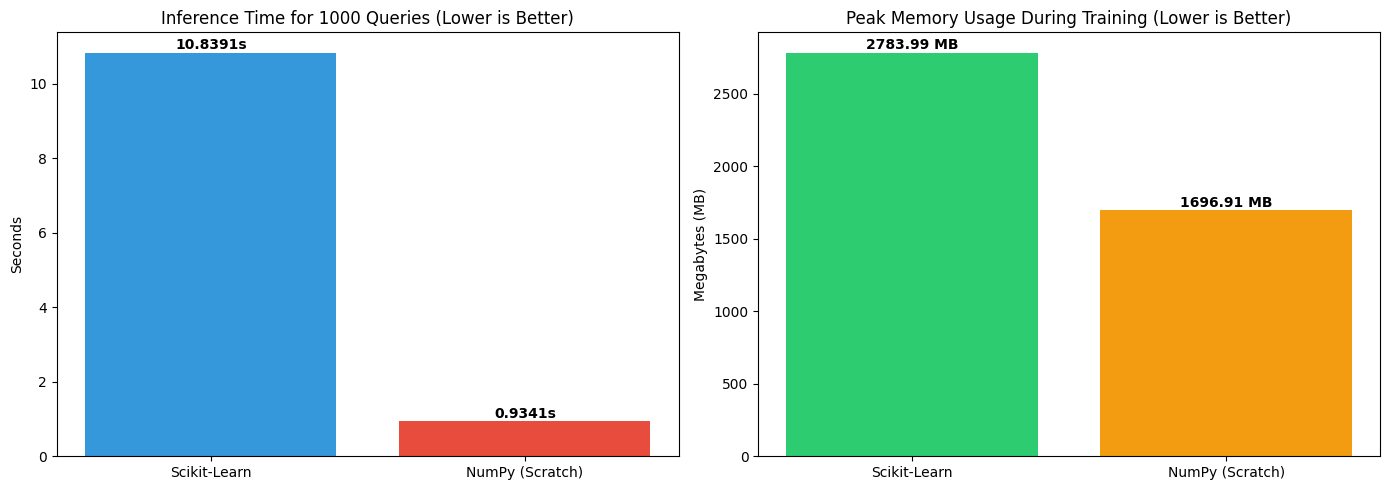

In [6]:
import time
import tracemalloc
import random
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from IPython.display import display, HTML

warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# CONFIGURATION
# ---------------------------------------------------------
DATASET_PATH = "data/Final_Augmented_dataset_Diseases_and_Symptoms.csv"
NUM_INFERENCE_QUERIES = 1000  # Number of simulated patients

print("🚀 INITIALIZING BENCHMARK PIPELINE...")
print("-" * 50)

# Initialize models
clf_sklearn = DiseaseClassifier(model_name="sklearnNaiveBayes")
clf_simple = DiseaseClassifier(model_name="simpleClassifierModel")

benchmark_results = {
    "Metrics": ["Training Time (sec)", "Peak Memory (MB)", "Inference Time - 1000 Queries (sec)", "Accuracy (%)"]
}

# ---------------------------------------------------------
# PHASE 1: TRAINING BENCHMARK (Time & Memory)
# ---------------------------------------------------------
print("[1/4] Benchmarking Scikit-Learn Training...")
tracemalloc.start()
start_t = time.time()
clf_sklearn.train(DATASET_PATH)
time_sk = time.time() - start_t
_, peak_mem_sk = tracemalloc.get_traced_memory()
tracemalloc.stop()

print("[2/4] Benchmarking From-Scratch Training...")
tracemalloc.start()
start_t = time.time()
clf_simple.train(DATASET_PATH)
time_sim = time.time() - start_t
_, peak_mem_sim = tracemalloc.get_traced_memory()
tracemalloc.stop()

# Convert Memory to MB
mem_sk_mb = peak_mem_sk / (1024 * 1024)
mem_sim_mb = peak_mem_sim / (1024 * 1024)

# ---------------------------------------------------------
# PHASE 2: METRICS PARITY CHECK
# ---------------------------------------------------------
print("[3/4] Evaluating Metric Parity...")
eval_sk = clf_sklearn.evaluate()
eval_sim = clf_simple.evaluate()

acc_sk = eval_sk.get('Accuracy', eval_sk.get('accuracy', 0)) * 100
acc_sim = eval_sim.get('Accuracy', eval_sim.get('accuracy', 0)) * 100

# ---------------------------------------------------------
# PHASE 3: INFERENCE STRESS TEST (Latency & Throughput)
# ---------------------------------------------------------
print(f"[4/4] Stress Testing Inference ({NUM_INFERENCE_QUERIES} synthetic queries)...")
vocab = list(clf_sklearn.symptoms_vocab)

# Generate 1000 random patient profiles (3 to 6 symptoms each)
synthetic_patients = [random.sample(vocab, random.randint(3, 6)) for _ in range(NUM_INFERENCE_QUERIES)]

start_t = time.time()
for patient in synthetic_patients:
    _ = clf_sklearn.predict(patient)
inf_sk = time.time() - start_t

start_t = time.time()
for patient in synthetic_patients:
    _ = clf_simple.predict(patient)
inf_sim = time.time() - start_t

# ---------------------------------------------------------
# REPORT GENERATION & VISUALIZATION
# ---------------------------------------------------------
print("\n✅ BENCHMARK COMPLETE! GENERATING REPORT...\n")

benchmark_results["Scikit-Learn (Scale-up)"] = [
    round(time_sk, 4), 
    round(mem_sk_mb, 2), 
    round(inf_sk, 4), 
    round(acc_sk, 2)
]
benchmark_results["NumPy (From Scratch)"] = [
    round(time_sim, 4), 
    round(mem_sim_mb, 2), 
    round(inf_sim, 4), 
    round(acc_sim, 2)
]

# Create a Pandas DataFrame for a clean table output
df_report = pd.DataFrame(benchmark_results)
df_report.set_index("Metrics", inplace=True)

# Display Table beautifully
display(HTML("<h3 style='color:#2E86C1;'>📊 Performance Benchmark Report</h3>"))
display(df_report.style.highlight_min(axis=1, color='lightgreen', subset=pd.IndexSlice[["Training Time (sec)", "Peak Memory (MB)", "Inference Time - 1000 Queries (sec)"], :]) \
                .highlight_max(axis=1, color='lightgreen', subset=pd.IndexSlice[["Accuracy (%)"], :]) \
                .format(precision=4))

# Plotting the Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Inference Time
bars1 = ax1.bar(["Scikit-Learn", "NumPy (Scratch)"], [inf_sk, inf_sim], color=['#3498DB', '#E74C3C'])
ax1.set_title(f"Inference Time for {NUM_INFERENCE_QUERIES} Queries (Lower is Better)")
ax1.set_ylabel("Seconds")
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.4f}s", ha='center', va='bottom', fontweight='bold')

# Plot 2: Memory Footprint
bars2 = ax2.bar(["Scikit-Learn", "NumPy (Scratch)"], [mem_sk_mb, mem_sim_mb], color=['#2ECC71', '#F39C12'])
ax2.set_title("Peak Memory Usage During Training (Lower is Better)")
ax2.set_ylabel("Megabytes (MB)")
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.2f} MB", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()